In [1]:
import time
import os
import numpy as np
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from modules import CHIP
from util import *

In [2]:
chip=CHIP(local_ip="192.168.1.15",remote_ip="192.168.1.10",remote_port=7,debug=0,init=True)
chip.set_device_cfg(deviceType=0,IsNew32=True,IsRERAM512=False)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=500,adc_last_gap=20)
chip.adc.set_gain_resistor(big_resistance=22e-3,small_resistance=200)
chip.adc.set_sample_times(adc_sample_times=8)
chip.clk_manager.set_cyc(delay1=10,delay2=10,delay3=50)

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 48229


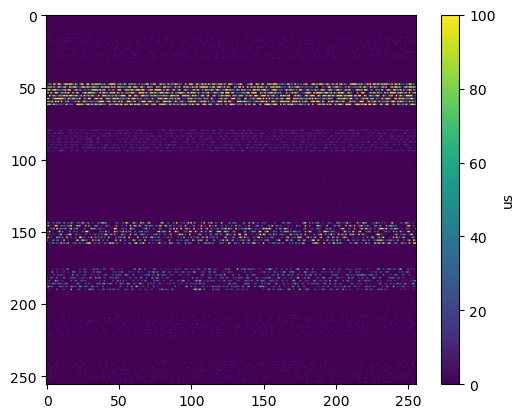

In [ ]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=0,row_type=0,col_type=0)


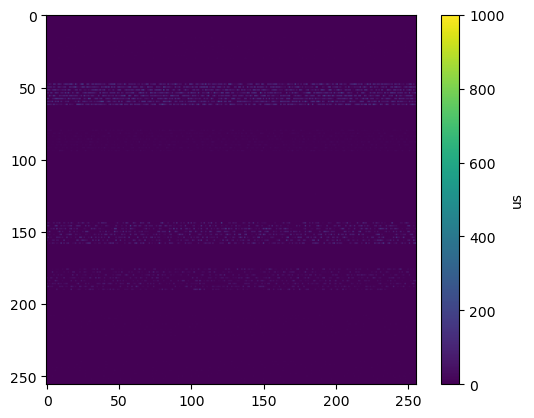

In [6]:
plot_cond(c,vmax=1000)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
def plot_v(v,figsize=(12,4),title=""):
    """
        绘制电压电导曲线图
    """
    plt.figure(figsize=figsize)
    plt.title = title

    # plt.subplot(1,2,1)
    plt.plot(v,marker='o', linestyle='-', linewidth=2,label="voltage")
    plt.ylabel("voltage(v)")
    plt.xlabel("TIA")
    plt.legend()

    # plt.subplot(1,2,2)
    # plt.plot(cond,marker='o', linestyle='-', linewidth=2,label="cond")
    # plt.ylabel("cond(us)")
    # plt.xlabel("TIA")

    # plt.legend()
    plt.show()

22


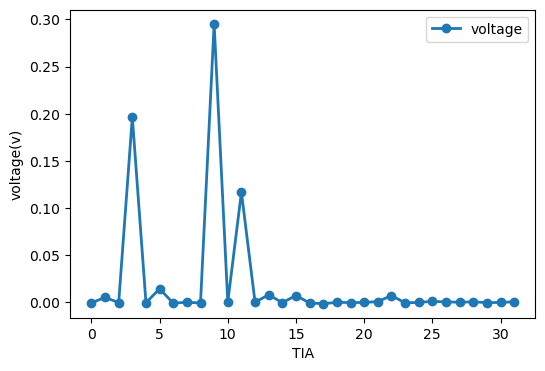

In [5]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(1)


# 先需要reset所有的latch
chip.set_cim_reset(reset_ans=0)
chip.set_cim_reset(reset_ans=1)

# # 选任意行配ltach
# # # 选任意行bank配32bit值
# chip.set_latch([11],row=True)
chip.set_bank([i for i in range(1)],row=True,value=0xFF)



chip.set_latch([100],row=False)
# chip.set_bank([100],row=False,value=0x1)

print(chip.setting.TIA_index_map(100,col=True))

chip.generate_read_pulse()
voltage = chip.get_tia_out([i for i in range(32)])

plot_v(v= voltage,figsize=(6,4))

In [3]:
ps_ddr_pos_start = 0xA100000 // 0x20  # 至少从这个ddr地址之后存放
ps_ddr_pos = ps_ddr_pos_start

In [4]:
v,c,r,ps_ddr_pos = chip.inference6(np.ones((10,64)),row_index=[i for i in range(0,256,4)],col_index=[0, 56, 117, 255],read_voltage=0.1,tg=5,gain=1,sub_base=False,from_row=True,split_type=4,ps_ddr_pos=ps_ddr_pos)
print(v.shape)

完整字节码: 55aa0a005080001d00000000
模式: 10
	帧头:            	字节码: 55 aa 0a
	指令: ps_ddr_addr	字节码: 00 50 80 00
	指令: ser_data   	字节码: 1d 00 00 00 00

Failed to send message:
完整字节码: 55aa09005080010000001003000000030100000302000003030000030400000305000003060000030700000308000003090000030a0000030b0000190100001a0000001b0100000b000000
模式: 9
	帧头:               	字节码: 55 aa 09
	指令: ps_ddr_addr   	字节码: 00 50 80 01
	指令: ps_data_length	字节码: 00 00 00 10
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_dac_v      	字节码: 03 01 00 00
	指令: pl_dac_v      	字节码: 03 02 00 00
	指令: pl_dac_v      	字节码: 03 03 00 00
	指令: pl_dac_v      	字节码: 03 04 00 00
	指令: pl_dac_v      	字节码: 03 05 00 00
	指令: pl_dac_v      	字节码: 03 06 00 00
	指令: pl_dac_v      	字节码: 03 07 00 00
	指令: pl_dac_v      	字节码: 03 08 00 00
	指令: pl_dac_v      	字节码: 03 09 00 00
	指令: pl_dac_v      	字节码: 03 0a 00 00
	指令: pl_dac_v      	字节码: 03 0b 00 00
	指令: pl_row_ctrli  	字节码: 19 01 00 00
	指令: pl_col_ctrli  	字节码: 1a 00 00 00
	指令: pl_row_col_swi	字节码: 1b 01 00 00
	指令: pl

In [6]:
chip.ps.receive_packet(4)

接收超时! 期望大小：4,实际大小：0,数据：


bytearray(b'')

### 准备输入数据并下放

In [ ]:
# 首次运行
# start_time = time.perf_counter()
ps_ddr_pos_start = 0xA100000 // 0x20  # 至少从这个ddr地址之后存放
ps_ddr_pos = ps_ddr_pos_start

In [ ]:
# 输入图片准备，从列输入
BATCH_SIZE = 1000  # 10000
test_loss_ = 0
correct = 0
test_samples = 0
test_loader = get_mnist_cropped(BATCH_SIZE, train=False, val=True)[0]
test_acc = []
output_row_num = 1
input_col_num = 196

test_criterion = nn.CrossEntropyLoss(reduction='sum')

max_samples = 1000  # 仅测试的最大样本数

b_col, b_row = [i for i in range(0, 128)], [0]

data_all = []

# 在数据收集阶段，为每个样本记录必要的元数据
sample_metadata = []  # 记录每个样本的元数据
current_sample_idx = 0

# 准备数据
for idx, (data, label) in enumerate(test_loader):
    if test_samples >= max_samples:
        break

    test_samples += data.size(0)
    data = data.reshape(data.shape[0], 196, 1)  # reshape为[BATCH_SIZE, H*W, 1]
    data_int = data.byte()  # 转换为 uint8 类型 [BATCH_SIZE, H*W, 1]
    binary_bits = []

    for i in range(7, -1, -1):  # 从第7位（最高位）到第0位（最低位）
        bit = (data_int >> i) & 1  # 提取第i位 [BATCH_SIZE, H*W, 1]
        binary_bits.append(bit)
    data_binary = torch.cat(binary_bits, dim=-1)  # 形状变为 [BATCH_SIZE, H*W, 8]
    for n in range(data_binary.shape[0]):
        # 为每个样本记录开始位置和位流数量
        sample_start_idx = len(data_all)
        bit_stream_count = data_binary.shape[2]  # 8个位流
        
        sample_metadata.append({
            'batch_idx': idx,
            'sample_idx': current_sample_idx,
            'data_start': sample_start_idx,
            'bit_stream_count': bit_stream_count,
            'label': label[n] if label is not None else None
            # 后续还要添加8个位的num_col_activated list
        })
        current_sample_idx += 1
        
        for k in range(data_binary.shape[2]):
            input_bit_stream = data_binary[n, :, k]  # 单次的位流输入
            input_col, output_row = [x for x, mask in zip(b_col, input_bit_stream) if mask == 1], b_row  # 这里input_bit_stream按顺序开启/关闭乱序的列号，但权重按照相同顺序提前映射好了，故是一致的

            # v_base,_,_ = chip.read4(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0,tg=5,gain=3,sub_base=False,from_row=False,split_type=3,row_type=0,col_type=0)
            # v,_,_ = chip.read4(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0.1,tg=5,gain=3,sub_base=False,from_row=False,split_type=3,row_type=0,col_type=0)
            # c = chip.voltage_to_cond(voltage = v - v_base)
            
            ps_ddr_pos,data=chip.read5(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,
                        split_type=3,row_type=0,col_type=0,ps_ddr_pos=ps_ddr_pos)
            data_all.append(data)


In [ ]:
# 只测试DMA传输+执行指令时间+数据返回
start_time = time.perf_counter()

In [ ]:
# 开始执行指令
ps_ddr_pos = chip.send_ps_run(flag=2,ps_ddr_pos_start=ps_ddr_pos_start,ps_ddr_pos=ps_ddr_pos)

overall_output = []
current_data_idx = 0
current_batch_idx = -1
batch_output = []  # 当前batch的输出列表

for sample_meta in sample_metadata:
    # 如果切换到新的batch，保存上一个batch的输出
    if sample_meta['batch_idx'] != current_batch_idx:
        if batch_output:  # 如果batch_output不为空，添加到overall_output
            overall_output.extend(batch_output)
        batch_output = []  # 重置为新的batch
        current_batch_idx = sample_meta['batch_idx']
    
    sample_output = np.zeros(output_row_num)
    
    # 处理当前样本的所有位流
    for bit_idx in range(sample_meta['bit_stream_count']):
        if current_data_idx < len(data_all):
            data_item = data_all[current_data_idx]

            v, c, r = chip.get_read5(*data_item)

            current_data_idx += 1
            
            partial_output = c[b_row]
            
            bit_weight = 2 ** (7 - bit_idx)  # 最高位权重128，最低位权重1
            sample_output += partial_output * bit_weight
    
    # 将当前样本输出添加到batch_output中
    batch_output.append(sample_output)
# 添加最后一个batch的输出
if batch_output:
    overall_output.extend(batch_output)
# 转换为tensor便于后续计算
overall_output = torch.tensor(np.array(overall_output), dtype=torch.float32)

print(f"处理完成: 总共{len(overall_output)}个样本，{len(sample_metadata)}个元数据记录")

chip.ps.receive_packet_check(bytes_num=4,message_check="cc550000")

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"DDR方法总用时: {elapsed_time:.6f} seconds")

In [ ]:
print(len(data_all))

In [ ]:
print(current_data_idx)

In [ ]:
print(hex(ps_ddr_pos))